In [1]:
import pandas as pd
import numpy as np

In [8]:
PATH = "./data"
TARGET = "SalePrice"

In [125]:
pd.set_option('display.max_rows', None)
pd.set_option('display.max_columns', None)
pd.set_option('display.width', None)
pd.set_option('display.expand_frame_repr', False)

In [10]:
df = pd.read_csv(PATH + "/train.csv")

### Create train and test set ###

In [11]:
from sklearn.model_selection import train_test_split

X = df.drop(columns=[TARGET])
y = df[TARGET]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=.2, shuffle=True, random_state=42
)

train_ids = X_train.pop("Id")
test_ids = X_test.pop("Id")

In [172]:
cat_cols = [col for col in X_train.columns if X_train[col].dtype == 'object']
num_cols = [col for col in X_train.columns if X_train[col].dtype != 'object']

### Data Cleaning ###

In [62]:
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.compose import ColumnTransformer

NAN_THRESHOLD = .4
nan_ratio = X_train.isna().sum() / X_train.shape[0]

high_nan_cols   = [col for col in nan_ratio.index if nan_ratio[col] > NAN_THRESHOLD]
num_impute_cols = [col for col in nan_ratio[nan_ratio > 0].index if col in num_cols]
# ohe_cols        = [col for col in X_train.columns if X_train[col].dtype == 'object']

['Alley', 'MasVnrType', 'FireplaceQu', 'PoolQC', 'Fence', 'MiscFeature']


<Figure size 2000x1200 with 0 Axes>

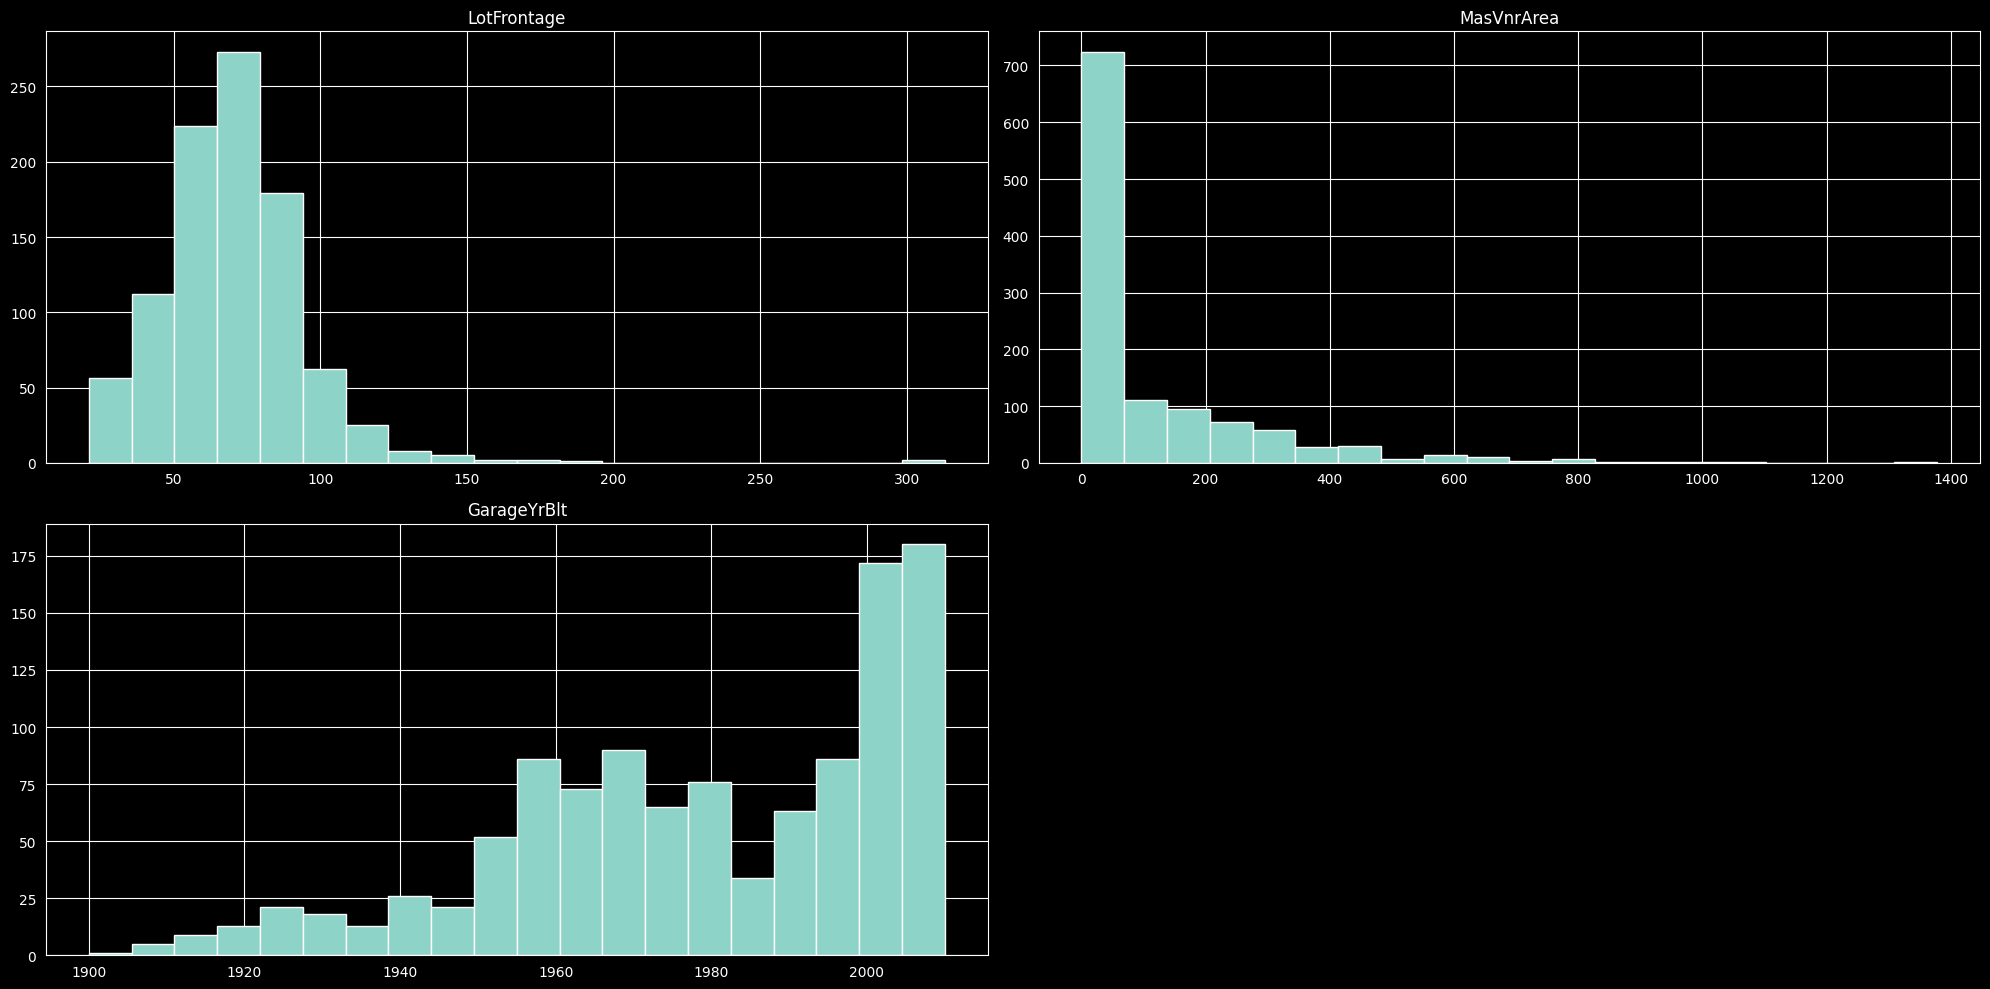

In [48]:
import matplotlib.pyplot as plt

X_train[num_impute_cols].describe()

plt.figure(figsize=(20, 12))
X_train[num_impute_cols].hist(bins=20, figsize=(20, 10))
plt.tight_layout()
plt.show()

In [303]:
# ohe_pipeline =  Pipeline([
#     ("cat", SimpleImputer(missing_values=np.nan, strategy="most_frequent")),
#     ("ohe", OneHotEncoder(handle_unknown="ignore", sparse_output=False)),
# ])

preprocessor = ColumnTransformer(
    transformers=[
        ("nan", "drop",                                                 high_nan_cols),
        ("cat", "drop",                                                 cat_cols),
        ("num", SimpleImputer(missing_values=np.nan, strategy="mean"),  num_impute_cols),
        # ("ohe", ohe_pipeline,                                           ohe_cols),
    ],
    remainder="passthrough",
    verbose_feature_names_out=False,
)

### Feature Selection ###

In [291]:
from sklearn.base import BaseEstimator, TransformerMixin

# class RFESelector(BaseEstimator, TransformerMixin):
#     def __init__(self, n_features):
#         self.n_features = n_features
#         self.selected_features = None
#
#     def fit(self, X, y):
#         X = pd.DataFrame(X)
#
#         model = LinearRegression()
#         self.rfe_ = RFE(estimator=model, n_features_to_select=self.n_features_to_select)
#         self.rfe_.fit(X, y)
#         self.features_selected = X.columns[self.rfe_.support_]
#
#         return self
#
#     def transform(self, X):
#         X = pd.DataFrame(X)
#         return X[self.features_selected]


### Full Pipeline ###

In [304]:
from sklearn.feature_selection import RFE
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import StandardScaler

preprocessing_pipeline = Pipeline([
    ("preprocessor", preprocessor),
    ("scaler", StandardScaler()),
    ("rfe", RFE(estimator=LinearRegression(), n_features_to_select=8))
])

preprocessing_pipeline.set_output(transform="pandas")

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('preprocessor', ...), ('scaler', ...), ...]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('nan', ...), ('cat', ...), ...]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'passthrough'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the differe

In [305]:
preprocessing_pipeline.fit(X_train, y_train)
X_train_t = preprocessing_pipeline.transform(X_train)
X_test_t = preprocessing_pipeline.transform(X_test)

### Linear Regression ###

In [310]:
from sklearn.linear_model import LinearRegression, Lasso, Ridge
from sklearn.model_selection import KFold, cross_validate
from sklearn.metrics import accuracy_score, f1_score, roc_auc_score, precision_score, recall_score

kf = KFold(n_splits=5, shuffle=True, random_state=42)

model = LinearRegression()

cv_results = cross_validate(
    model,
    X_train_t,
    y_train,
    cv=kf,
    scoring=["r2", "neg_mean_absolute_percentage_error", "neg_root_mean_squared_error"],
    return_train_score=True,
)

cv_results_df = pd.DataFrame(cv_results)

train_rmse = -cv_results_df.mean()["train_neg_root_mean_squared_error"]
test_rmse = -cv_results_df.mean()["test_neg_root_mean_squared_error"]

train_r2 = cv_results_df.mean()["train_r2"]
test_r2 = cv_results_df.mean()["test_r2"]

train_mape = -cv_results_df.mean()["train_neg_mean_absolute_percentage_error"]
test_mape = -cv_results_df.mean()["test_neg_mean_absolute_percentage_error"]

print(f"train rmse: {train_rmse}; test rmse: {test_rmse}")
print(f"train r2: {train_r2}; test r2: {test_r2}")
print(f"train mape: {train_mape}; test mape: {test_mape}")

train rmse: 35483.31569299821; test rmse: 35792.73011145381
train r2: 0.7887254460146329; test r2: 0.7825036262741097
train mape: 0.133230010004903; test mape: 0.1341312562846739


In [317]:
from sklearn.metrics import root_mean_squared_error, r2_score

model.fit(X_train_t, y_train)
y_pred = model.predict(X_test_t)

print(root_mean_squared_error(y_pred, y_test))
print(r2_score(y_pred, y_test))

38865.2088919737
0.7070747270722394
